In [1]:
import os       # for operating system interactions
import re       # for regular expressions
import glob    # for file handling
import numpy as np # for numerical operations
import pandas as pd # for data manipulation
from scipy.stats import zscore  # for z-score normalization
from scipy.spatial.distance import squareform # for distance matrix conversion
from scipy.cluster.hierarchy import linkage, fcluster   # for hierarchical clustering
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for better visualization
from scipy.stats import kruskal # for Kruskal-Wallis test

# Indices (MATLAB 1-based: n1=1200, n2=2400; Python slicing is 0-based and end-exclusive)
n1 = 1200
n2 = 2400

base_path = "./data/UCN3 stimulation/"

In [2]:
def min_max_norm(data):
    """
    Min-Max normalise each trace (row) independently to [0, 1].
    """
    data = np.asarray(data)
    min_vals = np.min(data, axis=1, keepdims=True)
    max_vals = np.max(data, axis=1, keepdims=True)

    return (data - min_vals) / (max_vals - min_vals)

In [3]:
# Convert p-value to custom significance symbols for visualisation
def pval_to_star(pvalue):
    """
    Converts a p-value into a string representing significance levels using hash marks and daggers.

    Parameters:
        pvalue (float): The p-value to evaluate.

    Returns:
        str: A string indicating statistical significance:
            '##'   → Highly significant (p ≤ 0.001)
            '#'    → Significant (p ≤ 0.01)
            '†'    → Marginally significant (p ≤ 0.05)
            'ns'   → Not significant
    """
    if pvalue <= 0.0001:
        return '##'  # Extremely significant
    elif pvalue <= 0.001:
        return '##'  # Highly significant
    elif pvalue <= 0.01:
        return '#'   # Significant
    elif pvalue <= 0.05:
        return '†'   # Marginally significant
    else:
        return 'ns'  # Not significant

In [4]:
def find_ucn3_folder(start_dir):
    hits = []
    for root, dirs, files in os.walk(start_dir):
        if "UCN3 stimulation" in root:
            if glob.glob(os.path.join(root, "*.csv")):
                hits.append(root)
    return hits

def ensure_base_path(base_path):
    print("Current working directory:", os.getcwd())
    if os.path.isdir(base_path):
        print("Base path exists:", base_path)
        return base_path

    print("Base path not found:", base_path)
    print("Searching under current directory...")
    hits = find_ucn3_folder(os.getcwd())

    if not hits:
        print("No hits under current directory. Searching under /home ...")
        hits = find_ucn3_folder("/home")

    if not hits:
        raise FileNotFoundError(
            "Could not find a folder containing 'UCN3 stimulation' with CSV files.\n"
            "Set base_path to an absolute path manually."
        )

    print("Found candidate folders:")
    for h in hits[:10]:
        print("  ", h)

    chosen = hits[0]
    print("Using detected base_path:", chosen)
    return chosen

# -----------------------------
# File lists
# -----------------------------
data_paths5HZ = [
    "G7 20231110 5hz 222sti.csv",
    "G7 20240201 5hz 223sti.csv",
    "G8 20231217 5hz 222sti.csv",
    "G8 20240202 5hz 223sti.csv",
    "G8 20240220 5hz 223sti.csv",
    "G8 20240301 5hz 223sti.csv",
    "G9 20231217 5hz 222sti.csv",
    "G9 20240202 5hz 223sti.csv",
    "G9 20240301 5hz 223sti.csv",
    "G9 20240307 5hz 223sti.csv",
    "G28 20240701 5hz 223sti.csv",
    "G28 20240704 5hz 223sti.csv",
    "G28 20240709 5hz 223sti.csv",
    "G29 20240703 5hz 223sti.csv",
    "G29 20240705 5hz 223sti.csv",
    "G29 20240711 5hz 223sti.csv",
    "G37 5hz 223sti 20240720 A.csv",
    "G37 5hz 223sti 20240720 B.csv",
    "G37 5hz 223sti 20240720 C.csv",
    "G37 5hz 223sti 20240724.csv",
]

data_paths10HZ = [
    "G7 20231110 10hz 222sti.csv",
    "G7 20240201 10hz 223sti.csv",
    "G8 20231218 10hz 222sti.csv",
    "G8 20240202 10hz 223sti.csv",
    "G8 20240220 10hz 223sti.csv",
    "G8 20240301 10hz 223sti.csv",
    "G9 20231218 10hz 222sti.csv",
    "G9 20240202 10hz 223sti.csv",
    "G9 20240228 10hz 223sti.csv",
    "G9 20240307 10hz 223sti.csv",
    "G28 20240701 10hz 223sti.csv",
    "G28 20240704 10hz 223sti.csv",
    "G28 20240709 10hz 223sti.csv",
    "G29 20240703 10hz 223sti.csv",
    "G29 20240705 10hz 223sti.csv",
    "G29 20240711 10hz 223sti.csv",
    "G37 10hz 223sti 20240720 A.csv",
    "G37 10hz 223sti 20240720 B.csv",
    "G37 10hz 223sti 20240721 A.csv",
    "G37 10hz 223sti 20240721 B.csv",
]

data_paths20HZ = [
    "G7 20231110 20hz 222sti.csv",
    "G7 20240202 20hz 223sti.csv",
    "G8 20231217 20hz 222sti.csv",
    "G8 20240202 20hz 223sti.csv",
    "G8 20240220 20hz 223sti.csv",
    "G8 20240301 20hz 223sti.csv",
    "G9 20231217 20hz 222sti.csv",
    "G9 20240202 20hz 223sti.csv",
    "G9 20240221 20hz 223sti.csv",
    "G9 20240307 20hz 223sti.csv",
    "G28 20240701 20hz 223sti.csv",
    "G28 20240704 20hz 223sti.csv",
    "G28 20240709 20hz 223sti.csv",
    "G29 20240703 20hz 223sti.csv",
    "G29 20240705 20hz 223sti.csv",
    "G29 20240711 20hz 223sti.csv",
    "G37 20hz 223sti 20240720 A.csv",
    "G37 20hz 223sti 20240720 B.csv",
    "G37 20hz 223sti 20240721 A.csv",
    "G37 20hz 223sti 20240721 B.csv",
]

paths = data_paths5HZ + data_paths10HZ + data_paths20HZ

# -----------------------------
# Main
# -----------------------------
base_path = ensure_base_path(base_path)

csvs = sorted(glob.glob(os.path.join(base_path, "*.csv")))
print(f"Found {len(csvs)} CSV files in base_path.")
print("First 10 CSVs:")
for p in csvs[:10]:
    print("  ", os.path.basename(p))

A = np.full(len(paths), np.nan, dtype=float)
missing = []
failed = []

for j, fname in enumerate(paths):
    filename = os.path.join(base_path, fname)

    if not os.path.isfile(filename):
        missing.append(fname)
        continue

    try:
        calcium = pd.read_csv(filename)

        # Drop first row (acceptance row)
        calcium = calcium.iloc[1:, :].reset_index(drop=True)

        # Rename first column to 'time'
        calcium.rename(columns={calcium.columns[0]: "time"}, inplace=True)

        calcium_array = calcium.to_numpy(dtype=float)

        time_all = calcium_array[:, 0]
        stim_slice = slice(n1 - 1, n2)  # MATLAB n1:n2 inclusive

        # Guard against too-short files
        if (n2 > len(time_all)) or (n1 < 1):
            failed.append((fname, "File shorter than requested stim window"))
            continue

        time_stim = time_all[stim_slice] - time_all[n1 - 1]
        calcium_stim = calcium_array[stim_slice, 1:]  # (T, Ncells)

        # Normalize each neuron (column-wise)
        calcium_stim = min_max_norm(calcium_stim)

        # Z-score each neuron (column-wise), then covariance across neurons
        X = zscore(calcium_stim, axis=0, ddof=1)
        cova = np.cov(X, rowvar=False)

        dist = 1.0 - cova
        np.fill_diagonal(dist, 0.0)

        # Hierarchical clustering (average linkage), 2 clusters
        Z = linkage(squareform(dist, checks=False), method="average")
        labels = fcluster(Z, t=2, criterion="maxclust")  # 1 or 2

        cluster_0 = calcium_stim[:, labels == 1]
        cluster_1 = calcium_stim[:, labels == 2]

        # Guard against weird clustering edge cases
        if cluster_0.size == 0 or cluster_1.size == 0:
            failed.append((fname, "One cluster ended up empty"))
            continue

        mean1 = np.mean(cluster_0, axis=1)
        mean2 = np.mean(cluster_1, axis=1)

        # Corr between cluster means
        if np.std(mean1) == 0 or np.std(mean2) == 0:
            A[j] = np.nan
        else:
            A[j] = np.corrcoef(mean1, mean2)[0, 1]

    except Exception as e:
        failed.append((fname, repr(e)))

print("\nDone.")
print("A (corr between cluster means per file):")
print(A)

if missing:
    print(f"\nMissing {len(missing)} files (showing up to 30):")
    for m in missing[:30]:
        print("  ", m)

if failed:
    print(f"\nFailed on {len(failed)} files (showing up to 30):")
    for f, reason in failed[:30]:
        print("  ", f, "->", reason)

Current working directory: /home/kn356/Desktop/MePD_GABA-main/data_analysis
Base path exists: ./data/UCN3 stimulation/
Found 60 CSV files in base_path.
First 10 CSVs:
   G28 20240701 10hz 223sti.csv
   G28 20240701 20hz 223sti.csv
   G28 20240701 5hz 223sti.csv
   G28 20240704 10hz 223sti.csv
   G28 20240704 20hz 223sti.csv
   G28 20240704 5hz 223sti.csv
   G28 20240709 10hz 223sti.csv
   G28 20240709 20hz 223sti.csv
   G28 20240709 5hz 223sti.csv
   G29 20240703 10hz 223sti.csv

Done.
A (corr between cluster means per file):
[-0.64523435 -0.68789286 -0.66562543 -0.55472437 -0.66735039 -0.3740931
 -0.36423816 -0.48938825 -0.46529069 -0.46195882 -0.26159055 -0.28690643
 -0.6061889  -0.25055953 -0.63713428 -0.33626814 -0.31950548 -0.63975554
 -0.36578649 -0.27158118 -0.37450053 -0.45145856 -0.78258242 -0.19612587
 -0.49274681 -0.39581861 -0.44882452 -0.52291844 -0.35159023 -0.63919747
 -0.70047076 -0.55511272 -0.45820239 -0.50332639 -0.2014789  -0.66178299
 -0.38164655 -0.70075518 -0.273

In [5]:
# Customise Matplotlib settings for consistent plot styling
rc_params = {
    'axes.grid': False,             # Turn off background gridlines
    'font.family': 'DejaVu Sans',   # Set global font for plot text
    'font.size': 15,                # Base font size for all elements
    'lines.linewidth': 2,           # Make plot lines thicker and easier to read
    'lines.markersize': 8,          # Larger markers for better visibility
    'xtick.major.size': 3,          # Length of major ticks on x-axis
    'ytick.major.size': 3,          # Length of major ticks on y-axis
    'xtick.labelsize': 15,          # Font size for x-axis tick labels
    'ytick.labelsize': 15,          # Font size for y-axis tick labels
    'xtick.bottom': True,           # Show ticks on bottom of x-axis
    'xtick.top': False,             # Hide ticks on top of x-axis
    'ytick.left': True,             # Show ticks on left of y-axis
    'ytick.right': False,           # Hide ticks on right of y-axis
    'axes.edgecolor': 'grey'        # Use grey colour for plot borders
}

# Apply each setting to Matplotlib's runtime configuration
for param, value in rc_params.items():
    plt.rcParams[param] = value

In [6]:
groups = np.r_[np.ones(20),
               2*np.ones(20),
               3*np.ones(len(A) - 40)].astype(int)


animals = np.array([p.split()[0] for p in paths])   # "G7", "G28", ...
unique_animals = pd.unique(animals)
mycolors = np.array([
    [140,  81,  10],
    [216, 179, 101],
    [246, 232, 195],
    [199, 234, 229],
    [ 90, 180, 172],
    [  1, 102,  94]
]) / 255.0

palette = dict(zip(unique_animals, mycolors))
print(palette)

{np.str_('G7'): array([0.54901961, 0.31764706, 0.03921569]), np.str_('G8'): array([0.84705882, 0.70196078, 0.39607843]), np.str_('G9'): array([0.96470588, 0.90980392, 0.76470588]), np.str_('G28'): array([0.78039216, 0.91764706, 0.89803922]), np.str_('G29'): array([0.35294118, 0.70588235, 0.6745098 ]), np.str_('G37'): array([0.00392157, 0.4       , 0.36862745])}


In [7]:
animal_labels = np.array([
    re.match(r"(G\d+)", fname).group(1)
    for fname in paths
])

In [8]:
x_order = [0, 1, 3, 4, 6, 7, 8, 9 ]

def violin_swarm(xpos, values, animals, palette, marker):
    df = pd.DataFrame({
        "x": np.repeat(xpos, len(values)),
        "y": values,
        "c": animals
    })

    sns.violinplot(
        x="x", y="y", data=df,
        order=x_order,
        fill=False, color="k",
        linewidth=1.5,
        ax=ax
    )

    sns.swarmplot(
        x="x", y="y", hue="c", data=df,
        order=x_order,
        palette=palette,
        size=10,
        marker=marker,
        legend=False,
        ax=ax
    )

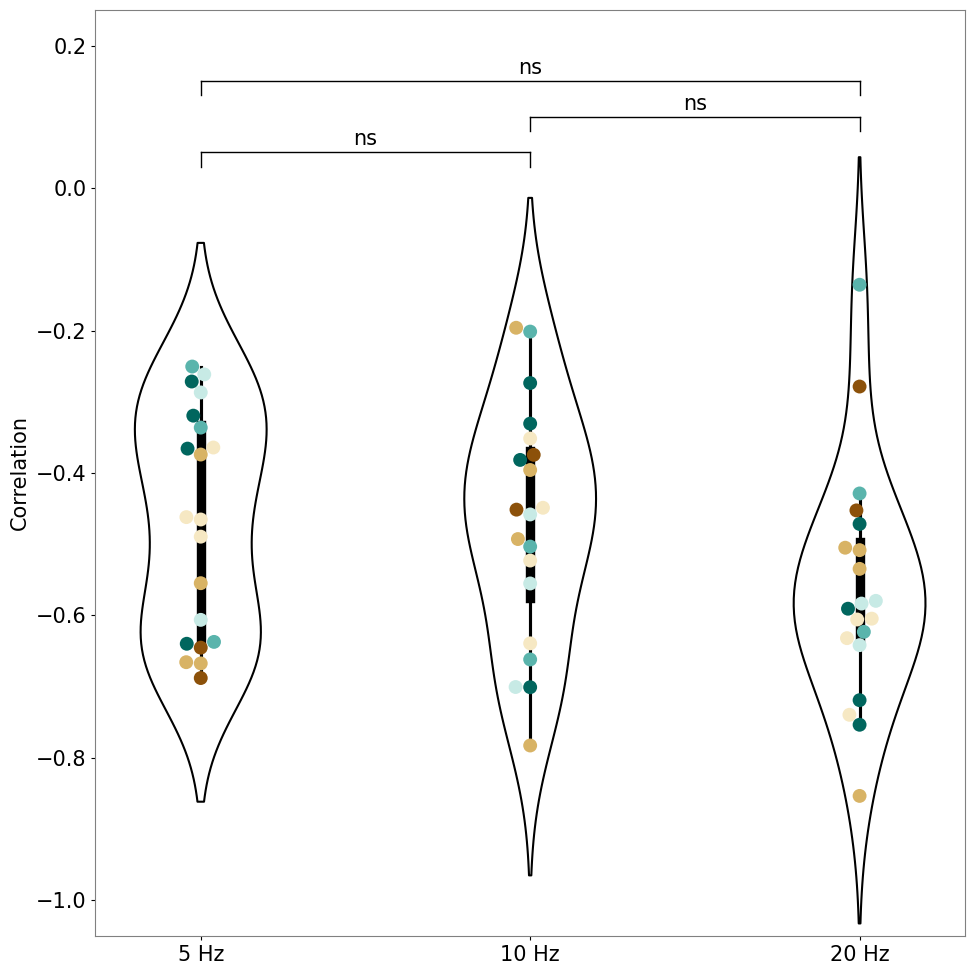

In [9]:

# split A by group and plot at spaced x positions
A = np.asarray(A, dtype=float)
groups_arr = np.asarray(groups)

vals_5  = A[groups_arr == 1]
anim_5  = animal_labels[groups_arr == 1]

vals_10 = A[groups_arr == 2]
anim_10 = animal_labels[groups_arr == 2]

vals_20 = A[groups_arr == 3]
anim_20 = animal_labels[groups_arr == 3]

x_order = [0, 1,2, 3,4,5,6]
# =========================
# Figure
# =========================
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 1, 1)

# --- Violin Plots ---
violin_swarm(1, vals_5, anim_5, palette, marker="o")
violin_swarm(3, vals_10, anim_10, palette, marker="o", )
violin_swarm(5, vals_20, anim_20, palette, marker="o")

# =========================
# Axes
# =========================
ax.set_ylabel("Correlation")
ax.set_xlabel("")
ax.set_xticks(
    [1, 3, 5],
    labels=["5 Hz", "10 Hz", "20 Hz"]
)
ax.set_ylim(-1.05, 0.25)

# =========================
# Statistics bars (same style as your example)
# Pick whichever comparisons you want
# =========================
# 5 vs 10
y = 0.05
ax.plot([1, 3], [y, y], "k-", lw=1)
ax.plot([1, 1], [y, y-0.02], "k-", lw=1)
ax.plot([3, 3], [y, y-0.02], "k-", lw=1)
_, p = kruskal(vals_5[np.isfinite(vals_5)], vals_10[np.isfinite(vals_10)])
ax.annotate(pval_to_star(p), (2, y+0.01), ha="center")
# 10 vs 20
y = 0.10
ax.plot([3, 5], [y, y], "k-", lw=1)
ax.plot([3, 3], [y, y-0.02], "k-", lw=1)
ax.plot([5, 5], [y, y-0.02], "k-", lw=1)
_, p = kruskal(vals_10[np.isfinite(vals_10)], vals_20[np.isfinite(vals_20)])
ax.annotate(pval_to_star(p), (4, y+0.01), ha="center")
# 5 vs 20
y = 0.15
ax.plot([1, 5], [y, y], "k-", lw=1)
ax.plot([1, 1], [y, y-0.02], "k-", lw=1)
ax.plot([5, 5], [y, y-0.02], "k-", lw=1)
_, p = kruskal(vals_5[np.isfinite(vals_5)], vals_20[np.isfinite(vals_20)])
ax.annotate(pval_to_star(p), (3, y+0.01), ha="center")

plt.tight_layout()
plt.savefig("Fig_dist_violin_swarm.svg", dpi=600, bbox_inches="tight")
plt.show()